<a href="https://colab.research.google.com/github/Muskan99113-cell/mushroom-classification-ml/blob/main/mushroom_classification_with_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Classification — Poisonous vs Non-Poisonous

### Normalization + Decision Tree + Naive Bayes + SVM + KNN

**Goal:** Predict whether a mushroom is **Poisonous** or **Non-Poisonous (Edible)** using its physical/categorical features.

**Models used:**
1. Decision Tree
2. Naive Bayes (CategoricalNB)
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)

The notebook also performs categorical encoding and **Min-Max normalization** for the distance-based models.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import CategoricalNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 2. Load Dataset

Upload `mushroom.csv` in Colab, or change `DATA_PATH` if your CSV has another name.

In [2]:
# If using Google Colab, run this cell and select your CSV file.
from google.colab import files

uploaded = files.upload()
DATA_PATH = next((name for name in uploaded.keys() if name.lower().endswith(".csv")), "mushroom.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Saving 11_mushroom_edibility (1).csv to 11_mushroom_edibility (1).csv
Dataset shape: (600, 11)


,SampleID,CapShape,CapColor,Odor,GillSpacing,GillColor,StalkShape,RingNumber,Habitat,Population,Class
0,S0001,flat,gray,foul,crowded,brown,tapering,one,woods,scattered,poisonous
1,S0002,convex,brown,almond,close,white,tapering,none,grasses,several,edible
2,S0003,convex,gray,none,distant,black,enlarging,two,leaves,scattered,poisonous
3,S0004,flat,yellow,none,close,white,enlarging,one,woods,abundant,poisonous
4,S0005,knobbed,gray,fishy,close,pink,enlarging,one,urban,several,poisonous


## 3. Explore the Dataset

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())


Columns:
['SampleID', 'CapShape', 'CapColor', 'Odor', 'GillSpacing', 'GillColor', 'StalkShape', 'RingNumber', 'Habitat', 'Population', 'Class']

Data types:
SampleID       object
CapShape       object
CapColor       object
Odor           object
GillSpacing    object
GillColor      object
StalkShape     object
RingNumber     object
Habitat        object
Population     object
Class          object
dtype: object

Missing values:
SampleID       0
CapShape       0
CapColor       0
Odor           0
GillSpacing    0
GillColor      0
StalkShape     0
RingNumber     0
Habitat        0
Population     0
Class          0
dtype: int64

Class distribution:
Class
poisonous    347
edible       253
Name: count, dtype: int64


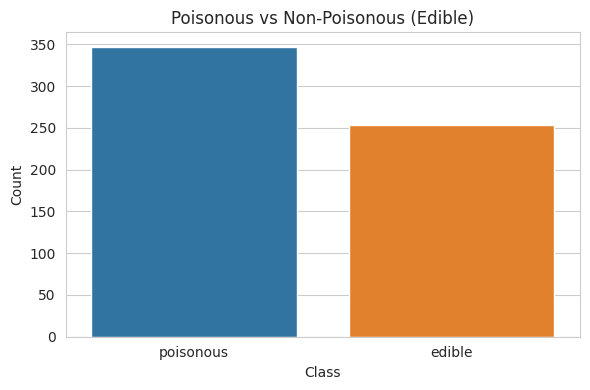

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df, hue="Class", legend=False)
plt.title("Poisonous vs Non-Poisonous (Edible)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Prepare Target: Poisonous vs Non-Poisonous

The original mushroom dataset commonly uses `edible` and `poisonous`.

For this project:
- **Poisonous = 1**
- **Non-Poisonous / Edible = 0**

The code also accepts common variants such as `p/e`, `poisonous/edible`, and `non-poisonous/nonpoisonous`.

In [5]:
# Clean target labels
df["Class"] = df["Class"].astype(str).str.strip().str.lower()

poisonous_values = {"p", "poisonous", "poison", "1"}
non_poisonous_values = {"e", "edible", "non-poisonous", "nonpoisonous", "non poisonous", "0"}

def map_target(value):
    if value in poisonous_values:
        return 1
    if value in non_poisonous_values:
        return 0
    return np.nan

df["Target"] = df["Class"].map(map_target)

if df["Target"].isna().any():
    print("Unrecognized class values:", df.loc[df["Target"].isna(), "Class"].unique())
    raise ValueError("Please update the target mapping for the class labels in your dataset.")

print(df["Target"].value_counts().rename(index={0: "Non-Poisonous", 1: "Poisonous"}))


Target
Poisonous        347
Non-Poisonous    253
Name: count, dtype: int64


## 5. Feature Preparation and Encoding

`SampleID` is only an identifier, so it is removed.

Because the predictors are categorical:
- **Ordinal/label encoding** is used for Decision Tree and Categorical Naive Bayes.
- **One-hot encoding + Min-Max normalization** is used for SVM and KNN. This avoids treating categories as if their integer codes had a real numeric order.

In [6]:
# Drop ID and target columns
drop_cols = [c for c in ["SampleID", "Class", "Target"] if c in df.columns]
X_raw = df.drop(columns=drop_cols).copy()
y = df["Target"].astype(int)

# Fill any unexpected missing categorical values
X_raw = X_raw.fillna("Unknown").astype(str)

print("Features used:", X_raw.columns.tolist())
print("Number of features:", X_raw.shape[1])


Features used: ['CapShape', 'CapColor', 'Odor', 'GillSpacing', 'GillColor', 'StalkShape', 'RingNumber', 'Habitat', 'Population']
Number of features: 9


## 6. Train-Test Split

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train_raw))
print("Testing samples :", len(X_test_raw))


Training samples: 450
Testing samples : 150


## 7. Categorical Encoding for Decision Tree and Naive Bayes

In [8]:
# Label encode each categorical feature.
# The same category mapping is applied to train and test data.
X_train_cat = pd.DataFrame(index=X_train_raw.index)
X_test_cat = pd.DataFrame(index=X_test_raw.index)

feature_encoders = {}

for col in X_train_raw.columns:
    le = LabelEncoder()
    le.fit(X_train_raw[col])

    X_train_cat[col] = le.transform(X_train_raw[col])

    # Handle a rare unseen test category safely
    known = set(le.classes_)
    X_test_cat[col] = X_test_raw[col].map(
        lambda v: le.transform([v])[0] if v in known else 0
    )

    feature_encoders[col] = le

X_train_cat = X_train_cat.astype(int)
X_test_cat = X_test_cat.astype(int)

print("Encoded training data:")
display(X_train_cat.head())


Encoded training data:


,CapShape,CapColor,Odor,GillSpacing,GillColor,StalkShape,RingNumber,Habitat,Population
356,1,1,2,1,0,1,1,4,1
71,1,1,2,0,4,1,1,3,2
94,2,3,3,0,3,1,1,4,3
384,1,2,3,2,1,0,1,4,2
237,2,0,4,0,4,0,1,0,0


## 8. Normalization for SVM and KNN

One-hot encoding converts each categorical value into a binary feature.  
Then **Min-Max normalization** scales every feature into the range **0 to 1**.

In [9]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_onehot = onehot.fit_transform(X_train_raw)
X_test_onehot = onehot.transform(X_test_raw)

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_onehot)
X_test_norm = scaler.transform(X_test_onehot)

print("One-hot shape:", X_train_onehot.shape)
print("Normalized range:",
      X_train_norm.min(), "to", X_train_norm.max())


One-hot shape: (450, 37)
Normalized range: 0.0 to 1.0


## 9. Model 1 — Decision Tree

Decision Tree can work directly with the encoded categorical features.

In [10]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=RANDOM_STATE
)

dt_model.fit(X_train_cat, y_train)
dt_pred = dt_model.predict(X_test_cat)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, zero_division=0))
print("Recall   :", recall_score(y_test, dt_pred, zero_division=0))
print("F1-score :", f1_score(y_test, dt_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test, dt_pred,
    target_names=["Non-Poisonous", "Poisonous"],
    zero_division=0
))


Decision Tree
Accuracy : 0.72
Precision: 0.835820895522388
Recall   : 0.6436781609195402
F1-score : 0.7272727272727273

Classification Report:
               precision    recall  f1-score   support

Non-Poisonous       0.63      0.83      0.71        63
    Poisonous       0.84      0.64      0.73        87

     accuracy                           0.72       150
    macro avg       0.73      0.73      0.72       150
 weighted avg       0.75      0.72      0.72       150



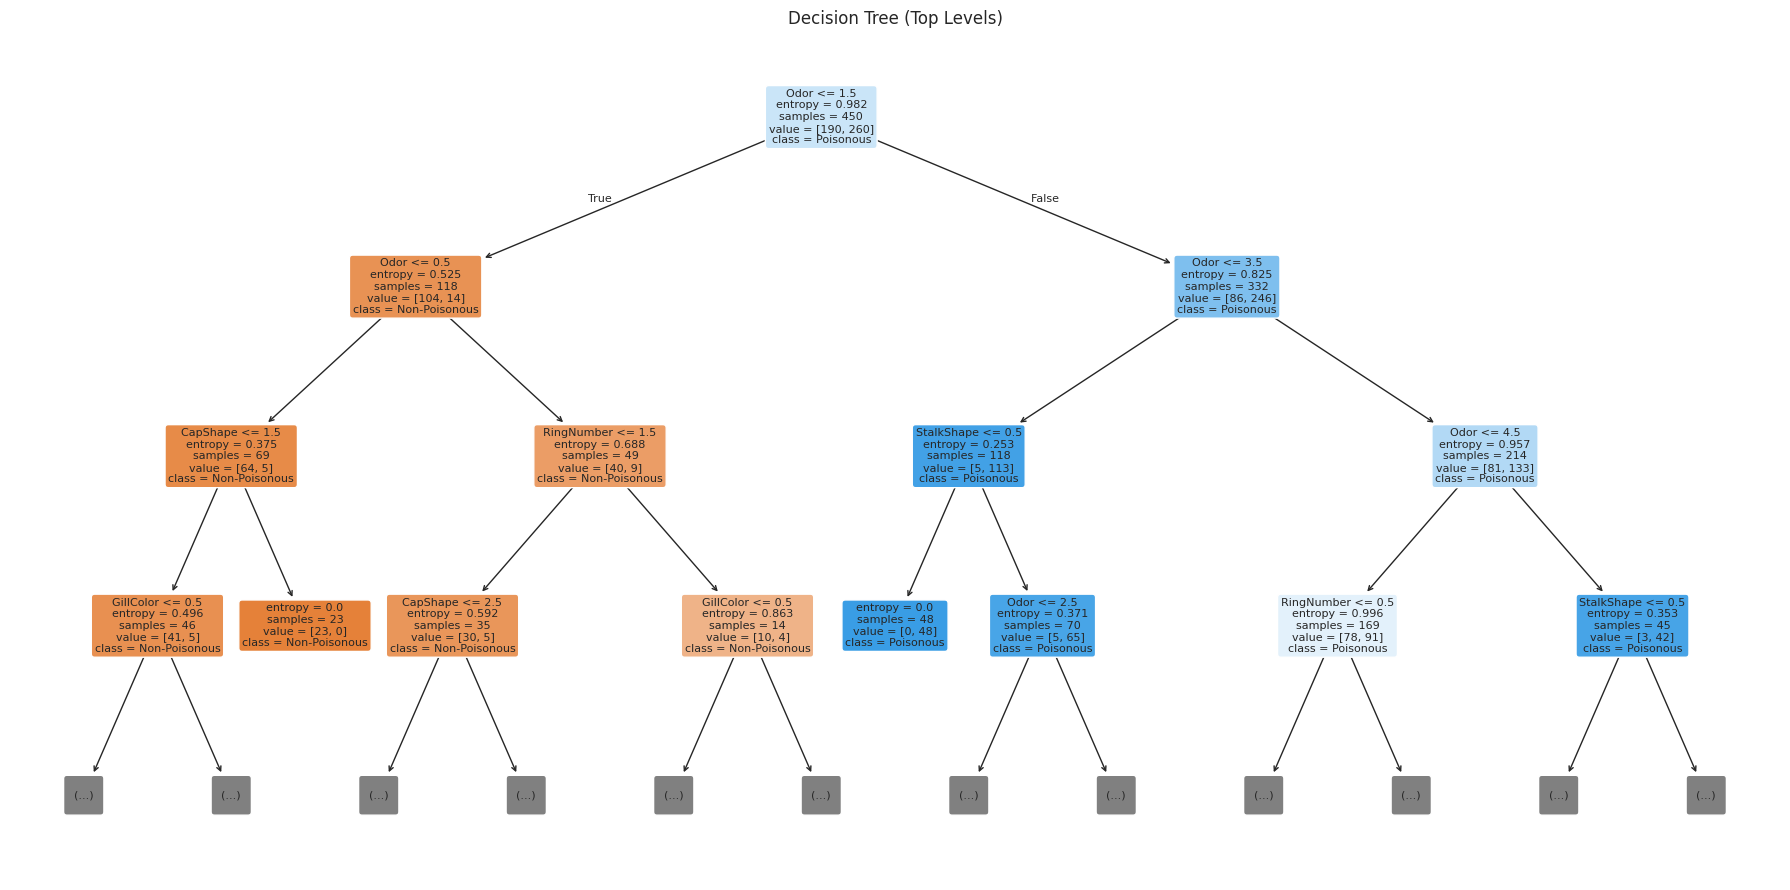

In [11]:
plt.figure(figsize=(18, 9))
plot_tree(
    dt_model,
    feature_names=X_raw.columns,
    class_names=["Non-Poisonous", "Poisonous"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree (Top Levels)")
plt.tight_layout()
plt.show()


## 10. Model 2 — Naive Bayes

`CategoricalNB` is used because the original predictor variables are categorical.

In [12]:
nb_model = CategoricalNB()

nb_model.fit(X_train_cat, y_train)
nb_pred = nb_model.predict(X_test_cat)

print("Naive Bayes")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, zero_division=0))
print("Recall   :", recall_score(y_test, nb_pred, zero_division=0))
print("F1-score :", f1_score(y_test, nb_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test, nb_pred,
    target_names=["Non-Poisonous", "Poisonous"],
    zero_division=0
))


Naive Bayes
Accuracy : 0.7466666666666667
Precision: 0.7752808988764045
Recall   : 0.7931034482758621
F1-score : 0.7840909090909091

Classification Report:
               precision    recall  f1-score   support

Non-Poisonous       0.70      0.68      0.69        63
    Poisonous       0.78      0.79      0.78        87

     accuracy                           0.75       150
    macro avg       0.74      0.74      0.74       150
 weighted avg       0.75      0.75      0.75       150



## 11. Model 3 — Support Vector Machine (SVM)

SVM is trained on the **one-hot encoded and normalized** feature matrix.

In [13]:
svm_model = SVC(
    kernel="rbf",
    random_state=RANDOM_STATE
)

svm_model.fit(X_train_norm, y_train)
svm_pred = svm_model.predict(X_test_norm)

print("SVM")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred, zero_division=0))
print("Recall   :", recall_score(y_test, svm_pred, zero_division=0))
print("F1-score :", f1_score(y_test, svm_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test, svm_pred,
    target_names=["Non-Poisonous", "Poisonous"],
    zero_division=0
))


SVM
Accuracy : 0.72
Precision: 0.7528089887640449
Recall   : 0.7701149425287356
F1-score : 0.7613636363636364

Classification Report:
               precision    recall  f1-score   support

Non-Poisonous       0.67      0.65      0.66        63
    Poisonous       0.75      0.77      0.76        87

     accuracy                           0.72       150
    macro avg       0.71      0.71      0.71       150
 weighted avg       0.72      0.72      0.72       150



## 12. Model 4 — K-Nearest Neighbors (KNN)

KNN is also trained on the **normalized** feature matrix because it is distance-based.

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_norm, y_train)
knn_pred = knn_model.predict(X_test_norm)

print("KNN")
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred, zero_division=0))
print("Recall   :", recall_score(y_test, knn_pred, zero_division=0))
print("F1-score :", f1_score(y_test, knn_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test, knn_pred,
    target_names=["Non-Poisonous", "Poisonous"],
    zero_division=0
))


KNN
Accuracy : 0.66
Precision: 0.6956521739130435
Recall   : 0.735632183908046
F1-score : 0.7150837988826816

Classification Report:
               precision    recall  f1-score   support

Non-Poisonous       0.60      0.56      0.58        63
    Poisonous       0.70      0.74      0.72        87

     accuracy                           0.66       150
    macro avg       0.65      0.65      0.65       150
 weighted avg       0.66      0.66      0.66       150



## 13. Confusion Matrices

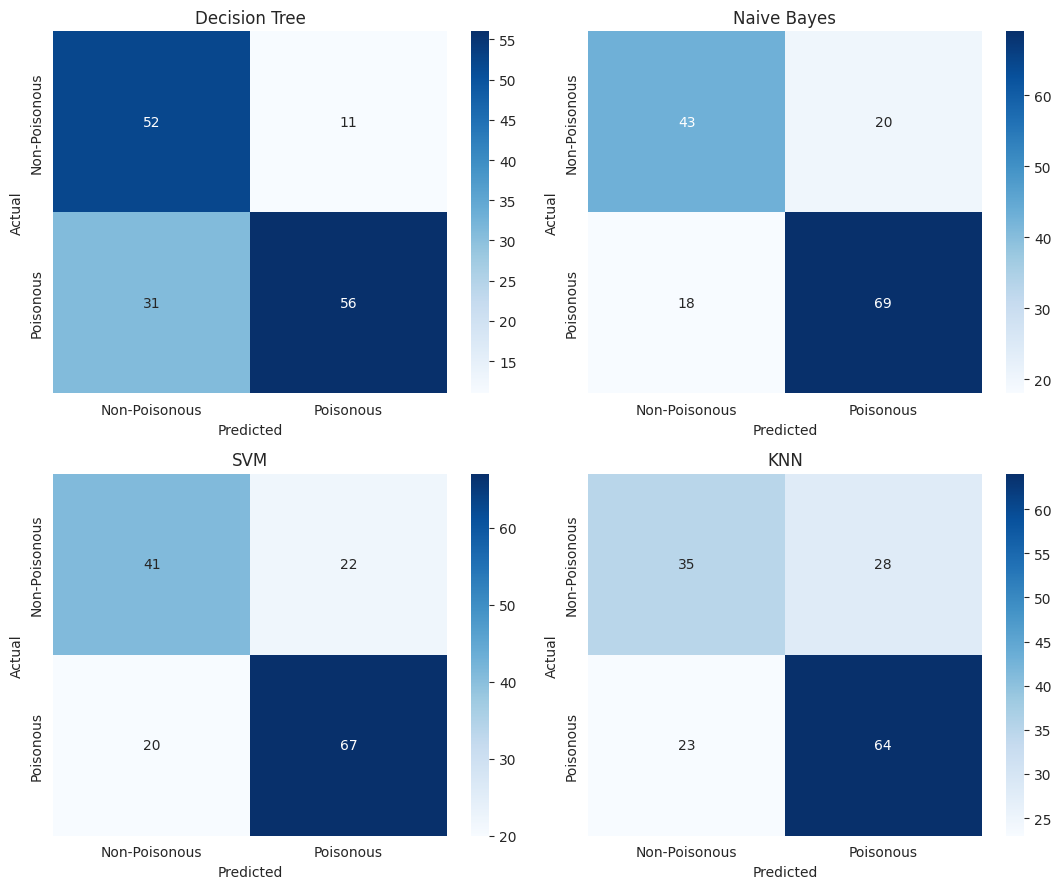

In [15]:
predictions = {
    "Decision Tree": dt_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred,
    "KNN": knn_pred
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (name, pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Non-Poisonous", "Poisonous"],
        yticklabels=["Non-Poisonous", "Poisonous"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 14. Model Comparison

In [16]:
results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    })

comparison = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(comparison)


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.746667,0.775281,0.793103,0.784091
1,Decision Tree,0.720000,0.835821,0.643678,0.727273
2,SVM,0.720000,0.752809,0.770115,0.761364
3,KNN,0.660000,0.695652,0.735632,0.715084


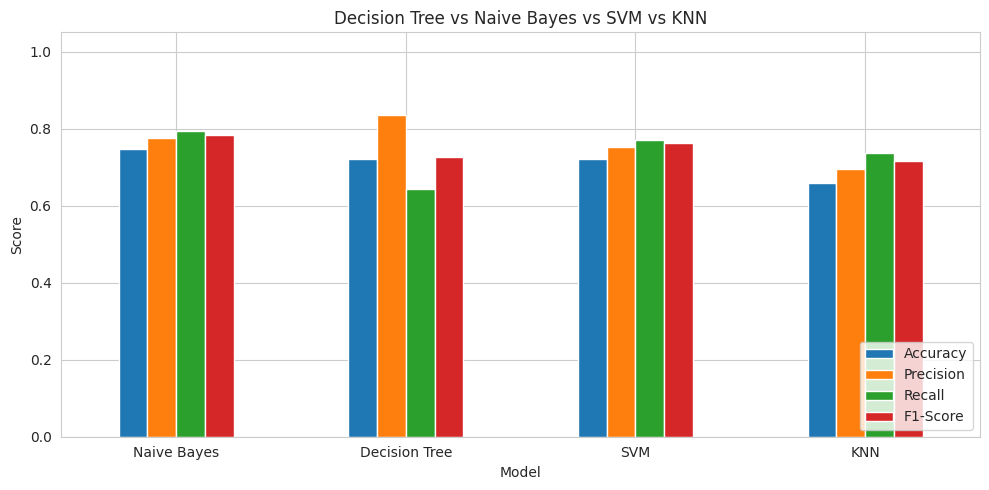

In [17]:
comparison_plot = comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Decision Tree vs Naive Bayes vs SVM vs KNN")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 15. Best Model

For this problem, **Recall for the Poisonous class is especially important** because predicting a poisonous mushroom as non-poisonous is the more dangerous error.

The code below automatically reports the best model by accuracy and the best model by poisonous-class recall.

In [18]:
best_accuracy_model = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]
best_recall_model = comparison.loc[comparison["Recall"].idxmax(), "Model"]

print("Best model by Accuracy:", best_accuracy_model)
print("Best model by Poisonous-class Recall:", best_recall_model)

print("\nFinal comparison:")
display(comparison)


Best model by Accuracy: Naive Bayes
Best model by Poisonous-class Recall: Naive Bayes

Final comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.746667,0.775281,0.793103,0.784091
1,Decision Tree,0.720000,0.835821,0.643678,0.727273
2,SVM,0.720000,0.752809,0.770115,0.761364
3,KNN,0.660000,0.695652,0.735632,0.715084


## 16. Conclusion

- The dataset is classified into **Poisonous** and **Non-Poisonous (Edible)** classes.
- Categorical features are encoded before model training.
- **Min-Max normalization** is applied after one-hot encoding for SVM and KNN.
- Four models are compared: **Decision Tree, Naive Bayes, SVM, and KNN**.
- Accuracy, Precision, Recall, F1-score, and confusion matrices are used for evaluation.
- For mushroom safety, poisonous-class **Recall** should be given special importance.

> **Note:** This is an educational ML classification project. A model prediction should not be used as a real-world guarantee that a mushroom is safe to eat.


## Visualizations

The following graphs help visualize the class distribution and compare the four ML models.

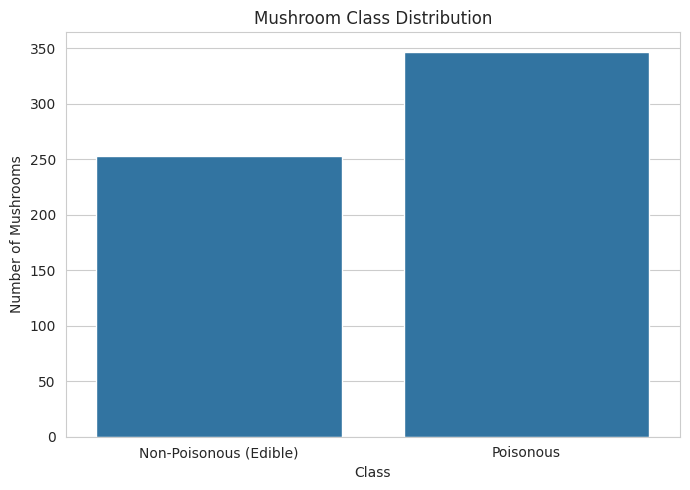

In [19]:
# 1. Poisonous vs Non-Poisonous class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x=y, order=[0, 1])
plt.xticks([0, 1], ['Non-Poisonous (Edible)', 'Poisonous'])
plt.xlabel('Class')
plt.ylabel('Number of Mushrooms')
plt.title('Mushroom Class Distribution')
plt.tight_layout()
plt.show()


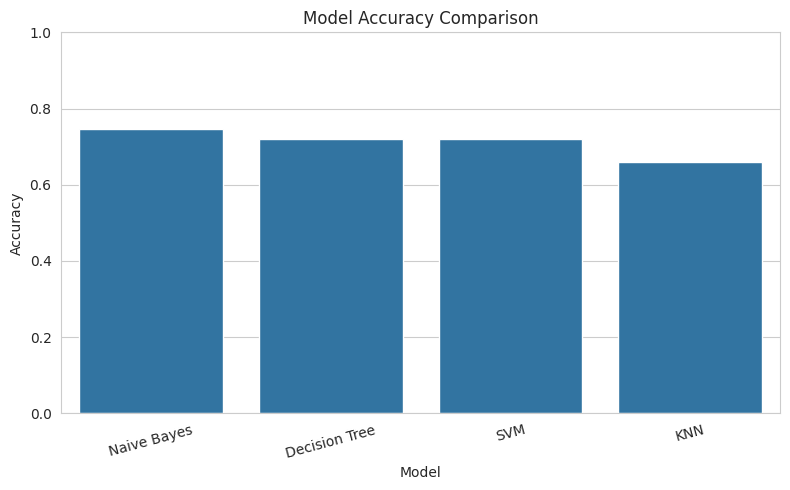

In [21]:
# 2. Model accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Model', y='Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


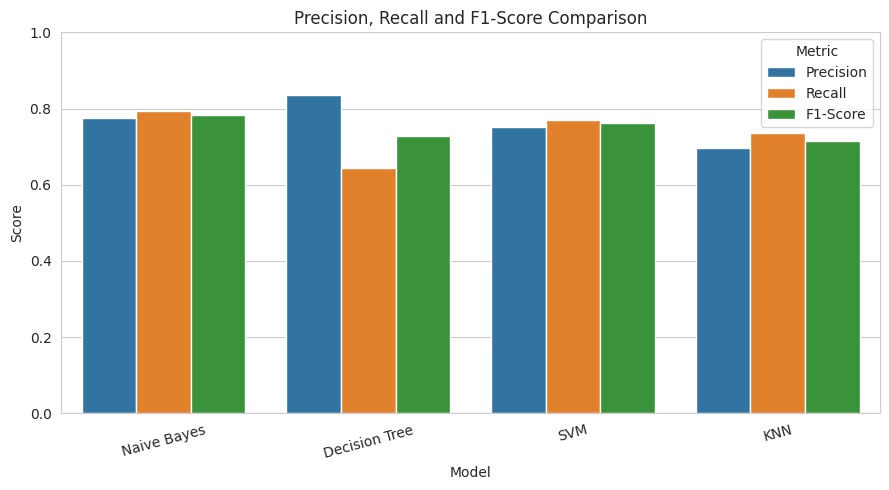

In [24]:
# 3. Precision, Recall and F1-score comparison

metrics_long = comparison.melt(
    id_vars='Model',
    value_vars=['Precision', 'Recall', 'F1-Score'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=metrics_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Model')
plt.title('Precision, Recall and F1-Score Comparison')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()